# Titanic - Machine Learning from Disaster

## Описание колонок и import
| Колонка        | Описание                                               |
|----------------|--------------------------------------------------------|
| PassengerId    | Уникальный идентификатор пассажира                    |
| Survived       | Целевая переменная: 0 — не выжил, 1 — выжил           |
| Pclass         | Класс билета (1 = 1-й, 2 = 2-й, 3 = 3-й)               |
| Name           | Имя пассажира                                          |
| Sex            | Пол                                                    |
| Age            | Возраст в годах                                        |
| SibSp          | Кол-во братьев/сестёр и супругов на борту             |
| Parch          | Кол-во родителей и детей на борту                      |
| Ticket         | Номер билета                                           |
| Fare           | Стоимость билета                                       |
| Cabin          | Номер каюты (много пропусков)                          |
| Embarked       | Порт посадки (C = Шербур, Q = Квинстаун, S = Саутгемптон) |


## Импорты

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp
from scipy.stats import kurtosis


import matplotlib.pyplot as plt
import seaborn as sns


from catboost import CatBoostClassifier, CatBoostRegressor

from category_encoders import OneHotEncoder
from sklearn.preprocessing import StandardScaler


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline


from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    auc, 
    roc_auc_score,
    roc_curve, 
    classification_report
)


from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)


import warnings
warnings.filterwarnings("ignore")

## Функции и классы

In [2]:
def plot_count(df, title):
    plt.figure(figsize=(6, 4))
    plt.title(title)
    sns.countplot(x=df)
    plt.grid()
    plt.show()


def plot_dist(df, title):
    plt.figure(figsize=(6, 4))
    sns.histplot(df, kde=True)
    plt.title(title)
    plt.grid()
    plt.show()

In [4]:
TITLE_MAPPING = {
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs",
    "Lady": "Royal",
    "the Countess": "Royal",
    "Sir": "Royal",
    "Don": "Royal",
    "Dona": "Royal",
    "Jonkheer": "Royal",
    "Dr": "Rare",
    "Rev": "Rare",
    "Major": "Rare",
    "Col": "Rare",
    "Capt": "Rare",
}


def preprocess(X):
    X = X.copy()
    # title из имени
    title_row(X)
        
    # заполняем Embarked
    X['Embarked'] = X['Embarked'].fillna(X['Embarked'].mode()[0])
    X['Embarked'] = X['Embarked'].str.lower()
    #заполняем Fare (1 пропущенное значение)
    X['Fare'] = X['Fare'].fillna(X['Fare'].mean())
    
    # добавляем категорию билетов
    quantiles = [0, 0.3, 0.6, 0.9, 1.0]
    labels = ["Low", "Medium", "High", "VeryHigh"]
    X["FareBin"] = pd.qcut(X["Fare"], q=quantiles, labels=labels)
    
    # Cabin
    X["Cabin"] = X["Cabin"].fillna("UKNOWN")
    X["Cabin"] = X["Cabin"].astype(str).str[0].str.lower()
    # Ticket
    X['Ticket'] = X['Ticket'].map(X['Ticket'].value_counts())        
    
    # Age предсказываем Catboost
    fill_age(X)
        
    # Parch и SibSp
    X["family_size"] = X["Parch"] + X["SibSp"] + 1
    X.drop(columns=["Parch", "SibSp"], inplace=True)
    X["is_alone"] = (X["family_size"] == 1).astype(int)
        
    #Age group
    conditions = [
        (X["Age"] <= 12),
        (X["Age"] <= 18),
        (X["Age"] <= 35),
        (X["Age"] <= 59),
        (X["Age"] > 59)
    ]
    
    choices = ["Child", "Teen", "YoungAdult", "Adult", "Senior"]
    X["AgeGroup"] = np.select(conditions, choices, default="Unknown")
    
    # is_male вместо Sex
    X["is_male"] = pd.get_dummies(X["Sex"], drop_first=True, dtype="int")
    X.drop(columns="Sex", inplace=True)
    X['Title'] = X['Title'].str.lower()
    
    
    return X
            

def title_row(X):
    X[["Name", "Title"]] = X["Name"].apply(lambda x: pd.Series(get_title(x)))
    X.drop("Name", axis=1, inplace=True)
    X["Title"] = X["Title"].replace(TITLE_MAPPING)

def get_title(x):
    name, title_surname = x.split(",")
    title, *surname = title_surname.split(".")
    surname = "".join(surname)
    title = title.strip()
    name = f"{name},{surname}"
    return name, title

def fill_age(df, plot=False):
    idx = df[df['Age'].isna()].index
    X = df.drop('Age', axis=1)
    y_train = df['Age'].loc[list(set(df.index) - set(idx))]
    X_test = X.loc[idx]
    X_train = X.loc[list(set(df.index) - set(idx))]

    model = CatBoostRegressor(
        iterations=1500,
        max_depth=5,
        cat_features=list(X.select_dtypes(include=['object', 'category']).columns),
        learning_rate=0.03,
        l2_leaf_reg=2,
        random_seed=42,
        verbose=0,
        loss_function='RMSE',
        eval_metric='MAPE'
    )
        
    model.fit(X_train, y_train, plot=plot)
    age_predicted = np.round(model.predict(X_test), 2)
    df.loc[idx, 'Age'] = age_predicted

In [37]:
def plot_roc_auc(y_true, y_pred_proba, title="ROC Curve"):
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

## 1. Загрузка данных

In [5]:
PATH_TO_DATA = "//Users/mac/Documents/!AI/data/!kaggle/titanic"

def load_data():
    train = pd.read_csv(f"{PATH_TO_DATA}/train.csv")
    print(f"Data shape {train.shape}")
    return train

In [6]:
df = load_data()

Data shape (891, 12)


## 2. Знакомство с данными

In [7]:
df.sample(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
841,842,0,2,"Mudd, Mr. Thomas Charles",male,16.0,0,0,S.O./P.P. 3,10.500,NaN,S
804,805,1,3,"Hedman, Mr. Oskar Arvid",male,27.0,0,0,347089,6.975,NaN,S
695,696,0,2,"Chapman, Mr. Charles Henry",male,52.0,0,0,248731,13.500,NaN,S


In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

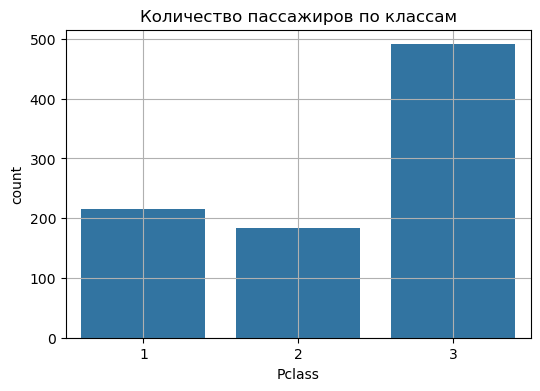

In [11]:
plot_count(df["Pclass"], "Количество пассажиров по классам")

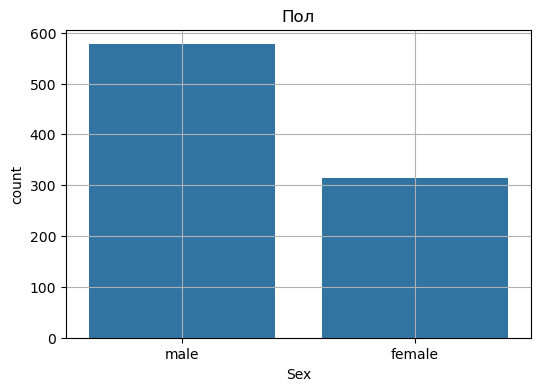

In [12]:
plot_count(df["Sex"], "Пол")

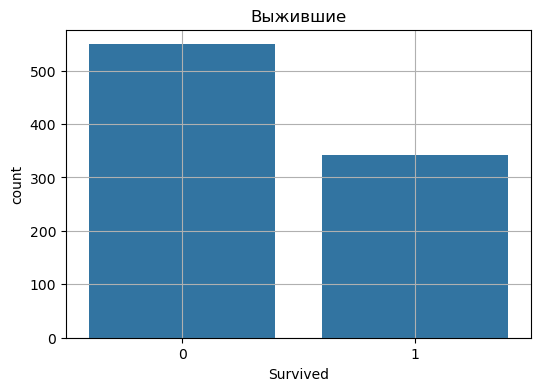

In [13]:
plot_count(df["Survived"], "Выжившие")

In [14]:
df["Embarked"].value_counts(dropna=False)

Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

## 3. Распределения

#### Fare

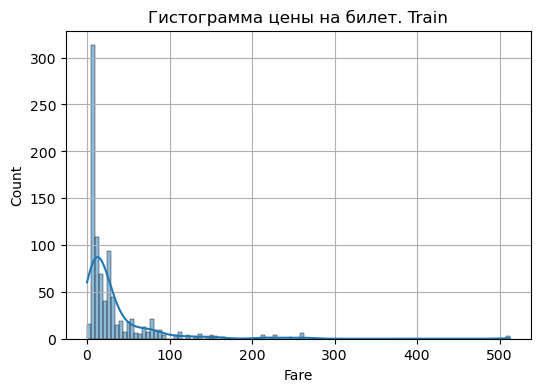

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [15]:
plot_dist(df["Fare"], "Гистограмма цены на билет. Train")
df['Fare'].describe()

#### Age

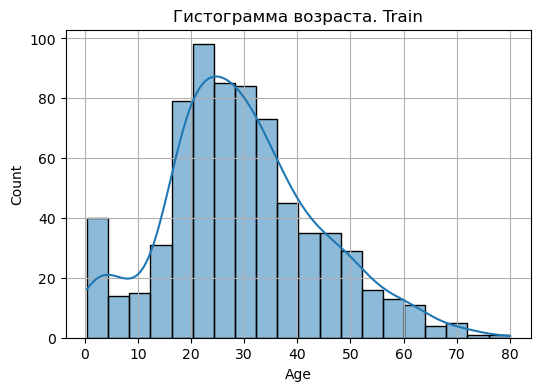

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [16]:
plot_dist(df["Age"], "Гистограмма возраста. Train")
df["Age"].describe()

## 4. Корреляция между признаками и таргетом

In [17]:
df_corr = df.corr(numeric_only=True)

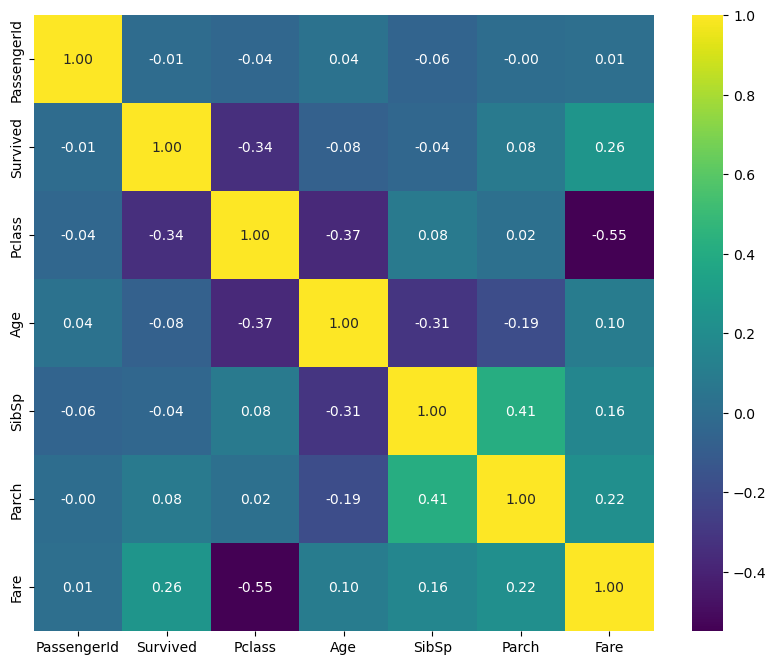

In [18]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr, annot=True, fmt=".2f", cmap="viridis")
plt.show()

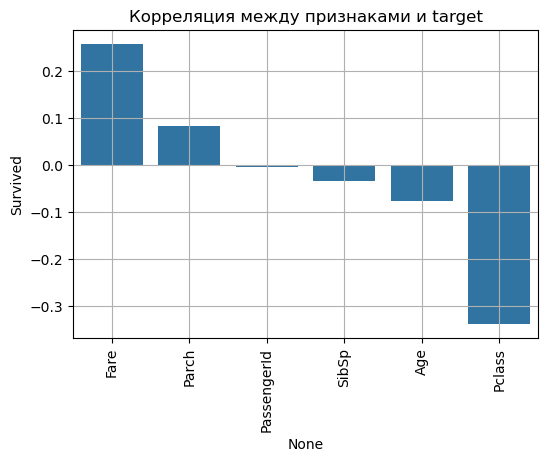

In [19]:
target_corr = (
    df.select_dtypes("number")
    .corr()["Survived"]
    .drop("Survived")
    .sort_values(ascending=False)
)

plt.figure(figsize=(6, 4))
sns.barplot(x=target_corr.index, y=target_corr)
plt.title("Корреляция между признаками и target")
plt.grid()
plt.xticks(rotation=90)
plt.show()

## 5. Prepocessing

In [20]:
X = df.drop(['Survived', 'PassengerId'], axis=1)
y = df['Survived']

X.head(3)

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [21]:
X = preprocess(X)
X.head(3)

,Pclass,Age,Ticket,Fare,Cabin,Embarked,Title,FareBin,family_size,is_alone,AgeGroup,is_male
0,3,22.0,1,7.2500,u,s,mr,Low,2,0,YoungAdult,1
1,1,38.0,1,71.2833,c,c,mrs,High,2,0,Adult,0
2,3,26.0,1,7.9250,u,s,miss,Low,1,1,YoungAdult,0


In [22]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.15, random_state=42, stratify=y_train_val
)


cat_features = list(X_train.select_dtypes(include=['object', 'category']).columns)

print(f'Train: {len(X_train) / len(X) * 100:.2f}%')
print(f'Val: {len(X_val) / len(X) * 100:.2f}%')
print(f'Test: {len(X_test) / len(X) * 100:.2f}%')

print(f'\n\n{cat_features = }')

Train: 67.90%
Val: 12.01%
Test: 20.09%


cat_features = ['Cabin', 'Embarked', 'Title', 'FareBin', 'AgeGroup']


## 6. Обучение модели Catboost

In [28]:
clf = CatBoostClassifier(
    iterations=3000,
    learning_rate=0.01,
    cat_features=cat_features,
    depth=6,
    l2_leaf_reg=4,
    loss_function="Logloss",
    eval_metric="Accuracy",
    class_weights=[1, 2],  # нужно компенсировать дисбаланс
    custom_metric=["F1", "AUC", "Accuracy"],
    verbose=100,
    random_seed=42   
)


clf.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
)

0:	learn: 0.8207885	test: 0.7702703	best: 0.7702703 (0)	total: 6.24ms	remaining: 18.7s
100:	learn: 0.8327360	test: 0.7702703	best: 0.7972973 (5)	total: 515ms	remaining: 14.8s
200:	learn: 0.8482676	test: 0.7770270	best: 0.7972973 (5)	total: 994ms	remaining: 13.8s
300:	learn: 0.8530466	test: 0.7770270	best: 0.7972973 (5)	total: 1.6s	remaining: 14.3s
400:	learn: 0.8637993	test: 0.7837838	best: 0.7972973 (5)	total: 2.22s	remaining: 14.4s
500:	learn: 0.8673835	test: 0.7905405	best: 0.7972973 (5)	total: 2.65s	remaining: 13.2s
600:	learn: 0.8733572	test: 0.7905405	best: 0.7972973 (5)	total: 3.08s	remaining: 12.3s
700:	learn: 0.8793309	test: 0.7905405	best: 0.7972973 (5)	total: 3.53s	remaining: 11.6s
800:	learn: 0.8817204	test: 0.7905405	best: 0.7972973 (5)	total: 3.96s	remaining: 10.9s
900:	learn: 0.8829152	test: 0.7905405	best: 0.7972973 (5)	total: 4.41s	remaining: 10.3s
1000:	learn: 0.8888889	test: 0.7972973	best: 0.7972973 (5)	total: 4.91s	remaining: 9.79s
1100:	learn: 0.8960573	test: 0.79

## 7. Анализ результатов 

In [32]:
analyze_model(X_train, X_test, y_train, y_test, clf, 'Catboost')

{'model': 'Catboost',
 'auc_train': 0.9586414902468336,
 'auc_test': 0.8416337285902502,
 'accuracy_train': 0.8859504132231405,
 'accuracy_test': 0.8044692737430168,
 'f1_test': 0.7586206896551724,
 'f1_train': 0.8547368421052632}

In [39]:
y_pred_test = clf.predict(X_test)
y_proba_test = clf.predict_proba(X_test)[:, 1]
y_pred_train = clf.predict(X_train)
y_proba_train = clf.predict_proba(X_train)[:, 1]

result = {
        'model': 'Catboost',
        'auc_train': roc_auc_score(y_train, y_proba_train),
        'auc_test': roc_auc_score(y_test, y_proba_test),
        'accuracy_train': accuracy_score(y_train, y_pred_train),
        'accuracy_test': accuracy_score(y_test, y_pred_test),
        'f1_test': f1_score(y_test, y_pred_test),
        'f1_train': f1_score(y_train, y_pred_train)
    }

pd.DataFrame([result])

,model,auc_train,auc_test,accuracy_train,accuracy_test,f1_test,f1_train
0,Catboost,0.958641,0.841634,0.88595,0.804469,0.758621,0.854737


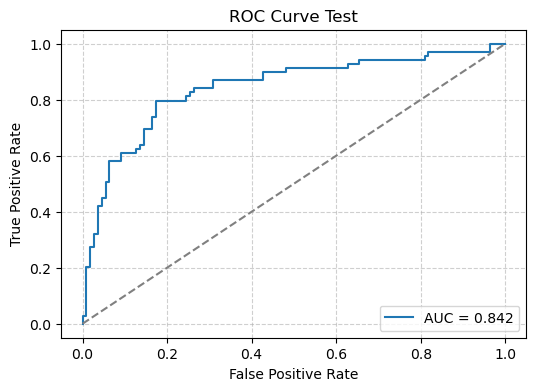

In [40]:
plot_roc_auc(y_test, y_proba_test, 'ROC Curve Test')

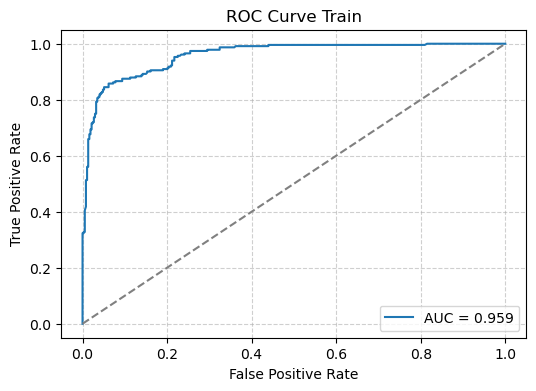

In [41]:
plot_roc_auc(y_train, y_proba_train, 'ROC Curve Train')